# 07 — Train BoggleCNN v2

**Goal:** Train BoggleCNN on v2-pipeline-extracted tiles to fix the train/inference distribution mismatch (currently 86.8% accuracy).

**Inputs:**
- `data/training-data-v2/tiles_augmented.npy` — Augmented tile images from notebook 06
- `data/training-data-v2/labels_augmented.npy` — Class indices

**Outputs:**
- `legacy/models/boggle_cnn_v2.pth` — Trained PyTorch weights
- `legacy/models/boggle_cnn_v2.onnx` — ONNX export for deployment

**Architecture:** BoggleCNN (3 conv + 2 FC, ~420K params), unchanged from v0.  
**Training:** Adam(lr=0.0025), batch=256, 3 epochs, CrossEntropyLoss.

**Usage:** Run notebook 06 first to generate the training data, then run all cells here in order.

## A. Setup

In [1]:
import sys
import random
from pathlib import Path
from collections import defaultdict

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.notebook import tqdm
from ultralytics import YOLO

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch {torch.__version__}, OpenCV {cv2.__version__}")

PyTorch 2.10.0, OpenCV 4.13.0


In [2]:
PROJECT_ROOT = Path.cwd().parent / "prototyping"
DATA_DIR = PROJECT_ROOT / "data" / "training-data-v2"
LEGACY_DIR = PROJECT_ROOT / "legacy"
MODEL_DIR = LEGACY_DIR / "models"
LABELED_RAW_DIR = PROJECT_ROOT / "data" / "labeled-raw"
LABELED_CSV = LABELED_RAW_DIR / "labeled-boards.csv"

print(f"Training data: {DATA_DIR} (exists: {DATA_DIR.exists()})")
print(f"Model output: {MODEL_DIR}")

# ── Pipeline ──────────────────────────────────────────────────────────────────
sys.path.insert(0, str(PROJECT_ROOT))

from pipeline import CLASS_LABELS, BoggleCNN, predict_tiles_batch, analyze_board
print(f"Pipeline loaded — {len(CLASS_LABELS)} classes")

Training data: /Users/thubbard/Documents/personal/programming/boggle-vision/prototyping/data/training-data-v2 (exists: True)
Model output: /Users/thubbard/Documents/personal/programming/boggle-vision/prototyping/legacy/models
Pipeline loaded — 32 classes


## B. Load Training Data

In [3]:
X = np.load(DATA_DIR / "tiles_augmented.npy")   # (N, 100, 100) uint8
y = np.load(DATA_DIR / "labels_augmented.npy")   # (N,) int

print(f"Loaded: X={X.shape}, y={y.shape}")
print(f"Classes present: {len(np.unique(y))}/{len(CLASS_LABELS)}")
print(f"Memory: {X.nbytes / 1024 / 1024:.1f} MB")
print(f"Dtype: X={X.dtype}, y={y.dtype}")

Loaded: X=(44800, 100, 100), y=(44800,)
Classes present: 32/32
Memory: 427.2 MB
Dtype: X=uint8, y=int64


## C. Dataset and DataLoaders

In [4]:
class BoggleTileDataset(Dataset):
    def __init__(self, tiles, labels):
        self.tiles = torch.from_numpy(tiles.astype(np.float32))   # (N, 100, 100)
        self.labels = torch.from_numpy(labels.astype(np.int64))   # (N,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.tiles[idx], self.labels[idx]


full_dataset = BoggleTileDataset(X, y)

# 85/10/5 split (matching v0)
n_total = len(full_dataset)
n_train = int(0.85 * n_total)
n_val = int(0.10 * n_total)
n_test = n_total - n_train - n_val

train_data, val_data, test_data = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE = 256
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")
print(f"Batches per epoch: {len(train_loader)}")

Train: 38080, Val: 4480, Test: 2240
Batches per epoch: 149


## D. Visualize a Batch

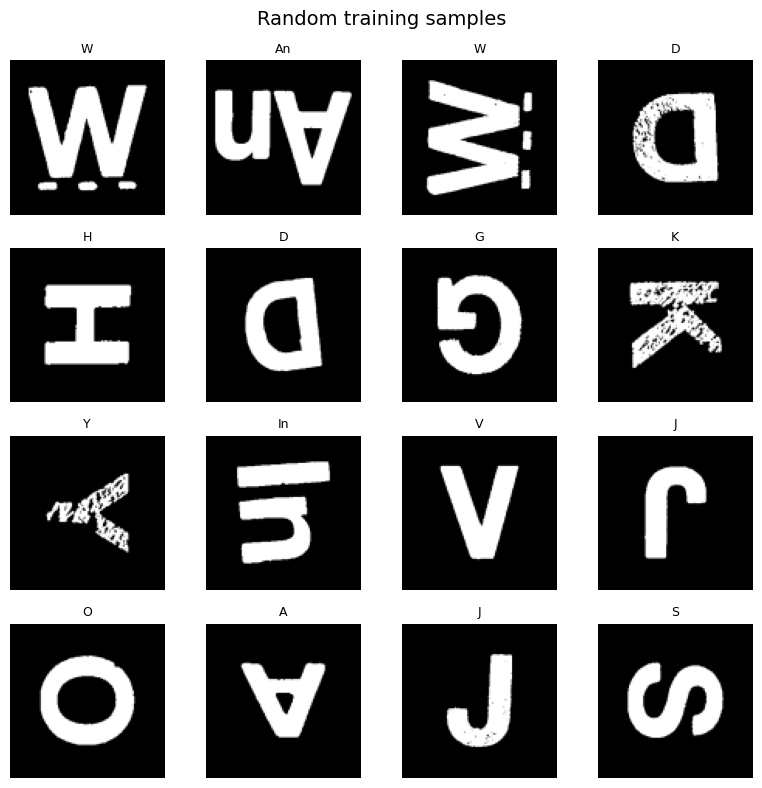

In [5]:
sample_batch_X, sample_batch_y = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Random training samples", fontsize=14)

indices = random.sample(range(len(sample_batch_X)), 16)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(sample_batch_X[idx].numpy(), cmap="gray")
    ax.set_title(CLASS_LABELS[sample_batch_y[idx].item()], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## E. Train

In [6]:
model = BoggleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0025)

NUM_EPOCHS = 3
history = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"Model: {sum(p.numel() for p in model.parameters()):,} params")
print(f"Training: Adam(lr=0.0025), batch={BATCH_SIZE}, epochs={NUM_EPOCHS}\n")

for epoch in range(NUM_EPOCHS):
    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        batch_X = batch_X.unsqueeze(1)  # (B, 1, 100, 100)
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.unsqueeze(1)
            logits = model(batch_X)
            val_loss += criterion(logits, batch_y).item()
            preds = logits.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += len(batch_y)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train loss: {avg_train_loss:.4f}  |  "
          f"Val loss: {avg_val_loss:.4f}  |  Val acc: {val_acc:.4f}")

Model: 419,744 params
Training: Adam(lr=0.0025), batch=256, epochs=3



Epoch 1/3:   0%|          | 0/149 [00:00<?, ?it/s]

  Train loss: 1.5658  |  Val loss: 0.0434  |  Val acc: 0.9962


Epoch 2/3:   0%|          | 0/149 [00:00<?, ?it/s]

  Train loss: 0.0413  |  Val loss: 0.0264  |  Val acc: 0.9982


Epoch 3/3:   0%|          | 0/149 [00:00<?, ?it/s]

  Train loss: 0.0422  |  Val loss: 0.0286  |  Val acc: 0.9971


## F. Training Curves

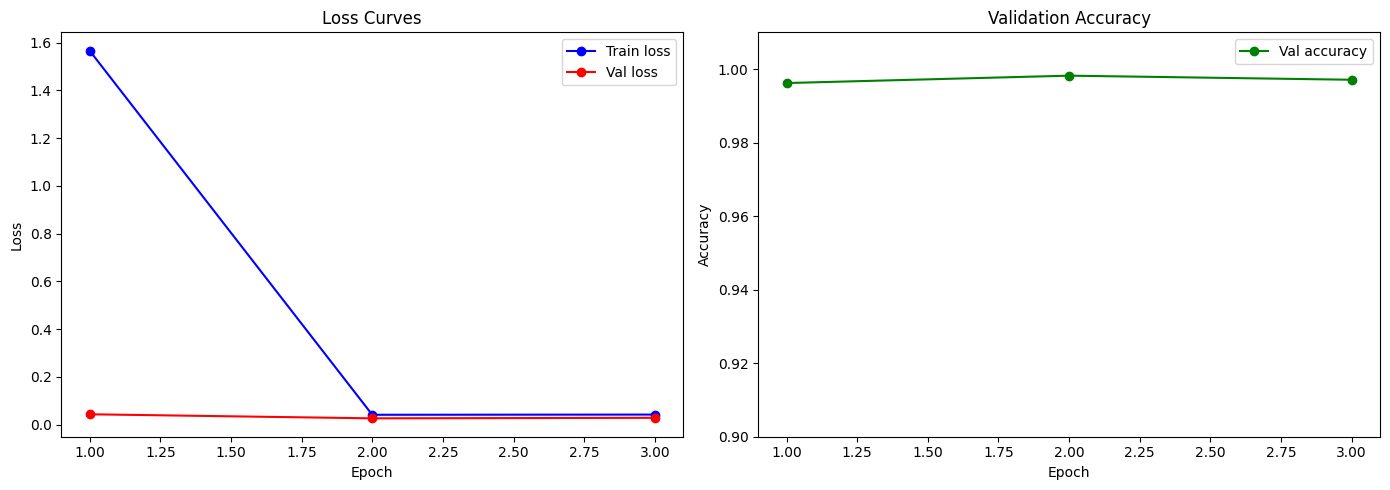

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], "b-o", label="Train loss")
ax1.plot(epochs, history["val_loss"], "r-o", label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()

ax2.plot(epochs, history["val_acc"], "g-o", label="Val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")
ax2.set_ylim(0.9, 1.01)
ax2.legend()

plt.tight_layout()
plt.show()

## G. Test Set Evaluation

In [8]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.unsqueeze(1)
        logits = model(batch_X)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.tolist())
        all_targets.extend(batch_y.tolist())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
test_acc = (all_preds == all_targets).mean()

print(f"Test accuracy: {test_acc:.4f} ({(all_preds == all_targets).sum()}/{len(all_targets)})")

Test accuracy: 0.9955 (2230/2240)


## H. Confusion Matrix

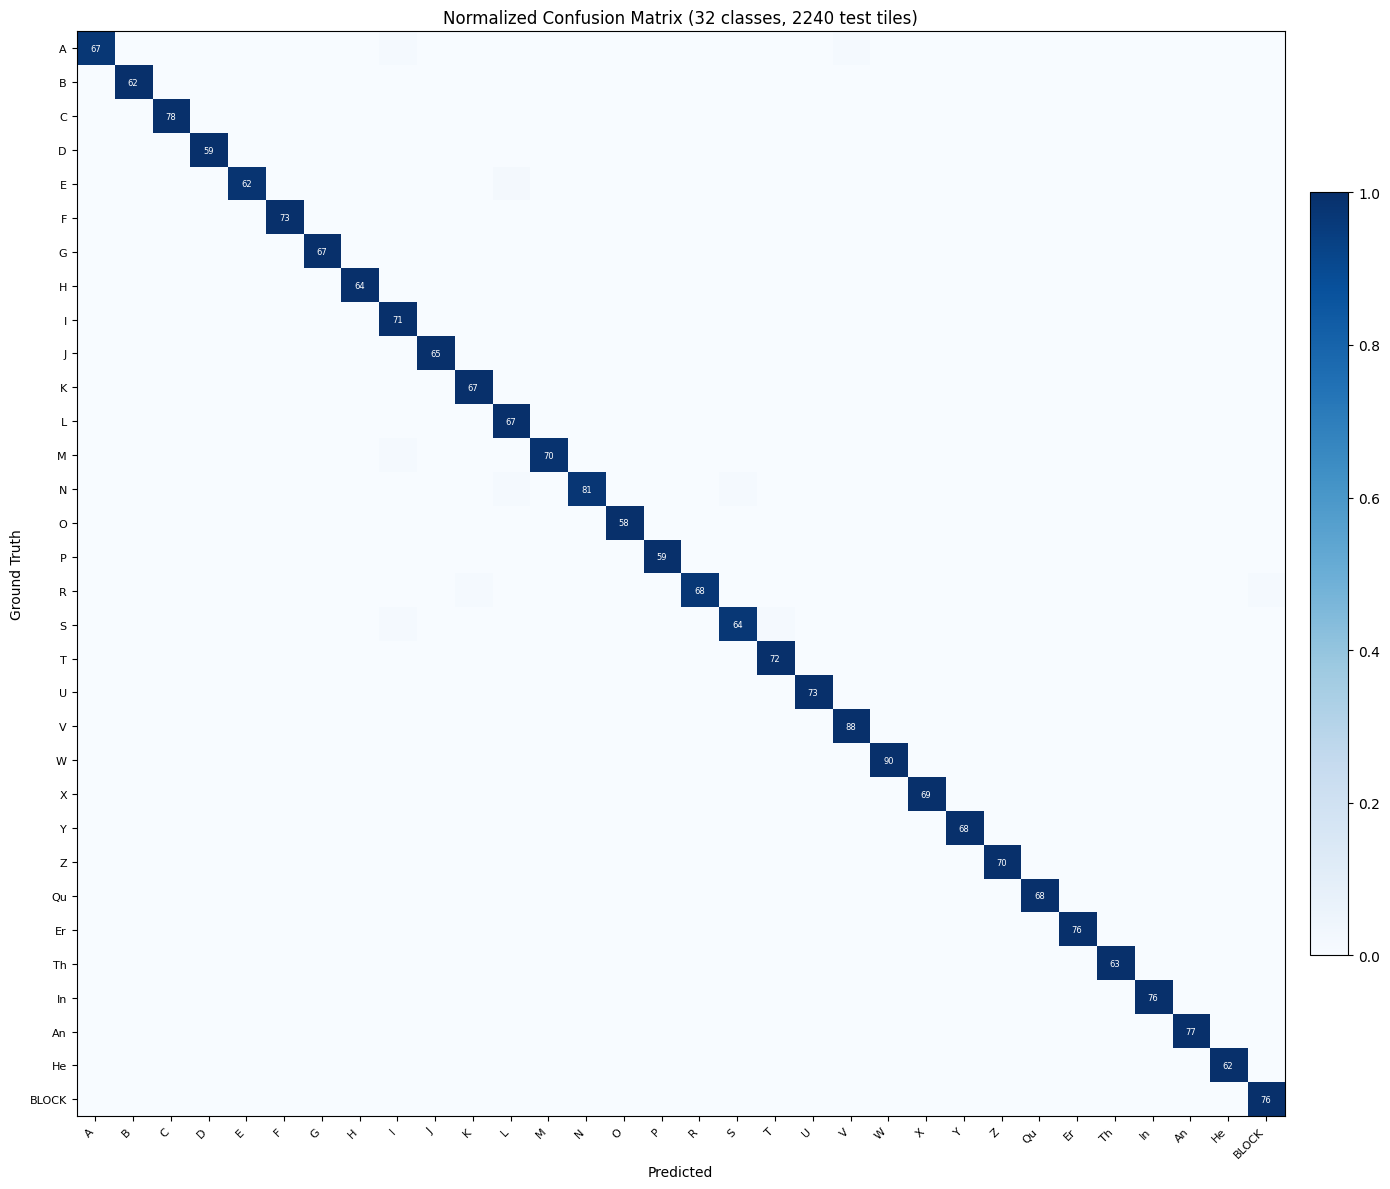


Top-10 mispredictions (GT → Pred, count):
      S → T    : 1
      S → I    : 1
      R → K    : 1
      R → BLOCK: 1
      N → S    : 1
      N → L    : 1
      M → I    : 1
      E → L    : 1
      A → V    : 1
      A → I    : 1


In [9]:
# Build confusion matrix over the test set
present_indices = sorted(set(all_targets.tolist()) | set(all_preds.tolist()))
present_labels = [CLASS_LABELS[i] for i in present_indices]
idx_to_pos = {idx: pos for pos, idx in enumerate(present_indices)}

n_cls = len(present_labels)
conf_matrix = np.zeros((n_cls, n_cls), dtype=int)
for t, p in zip(all_targets, all_preds):
    conf_matrix[idx_to_pos[t], idx_to_pos[p]] += 1

# Normalize by row (GT class)
row_sums = conf_matrix.sum(axis=1, keepdims=True).clip(min=1)
conf_norm = conf_matrix / row_sums

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(conf_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(n_cls))
ax.set_yticks(range(n_cls))
ax.set_xticklabels(present_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(present_labels, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground Truth")
ax.set_title(f"Normalized Confusion Matrix ({n_cls} classes, {conf_matrix.sum()} test tiles)")

for i in range(n_cls):
    for j in range(n_cls):
        v = conf_norm[i, j]
        if v > 0.05 or i == j:
            ax.text(j, i, f"{conf_matrix[i, j]}", ha="center", va="center",
                    fontsize=6, color="white" if v > 0.5 else "black")

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

# Top mispredictions
off_diag = [(conf_matrix[i, j], present_labels[i], present_labels[j])
            for i in range(n_cls) for j in range(n_cls)
            if i != j and conf_matrix[i, j] > 0]
off_diag.sort(reverse=True)

if off_diag:
    print("\nTop-10 mispredictions (GT → Pred, count):")
    for count, gt_l, pred_l in off_diag[:10]:
        print(f"  {gt_l:>5s} → {pred_l:<5s}: {count}")
else:
    print("\nNo mispredictions on test set!")

## I. Per-Class Accuracy

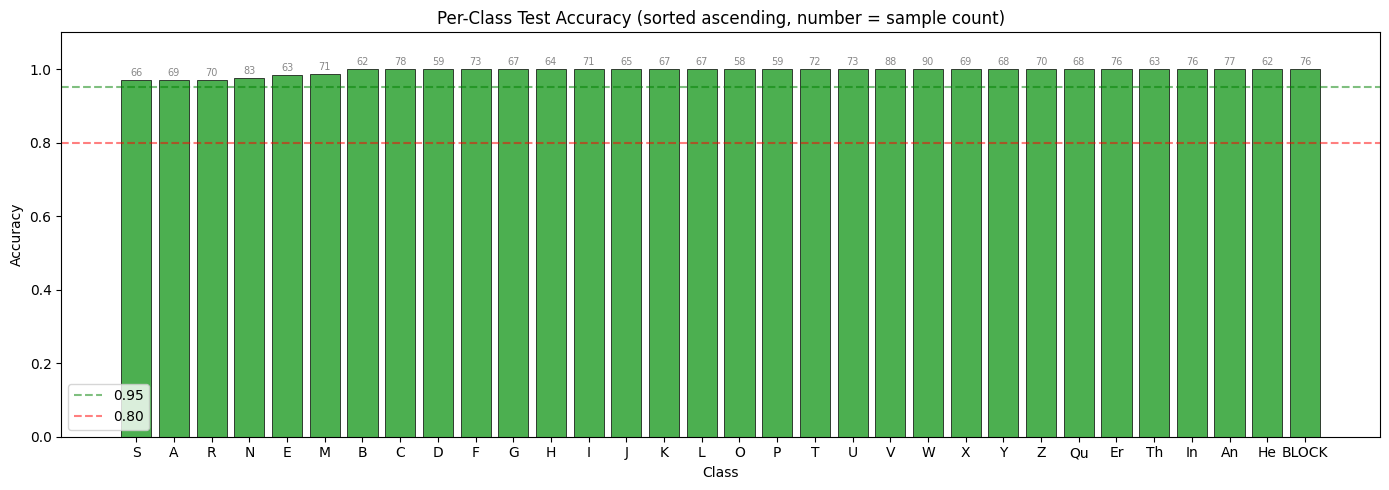


All classes ≥ 95% accuracy!


In [10]:
class_correct = defaultdict(int)
class_total = defaultdict(int)

for t, p in zip(all_targets, all_preds):
    label = CLASS_LABELS[t]
    class_total[label] += 1
    if t == p:
        class_correct[label] += 1

class_accs = []
for label in CLASS_LABELS:
    total = class_total.get(label, 0)
    if total == 0:
        continue
    correct = class_correct.get(label, 0)
    class_accs.append((label, correct / total, total))

class_accs.sort(key=lambda x: x[1])
ca_labels = [x[0] for x in class_accs]
ca_accs = [x[1] for x in class_accs]
ca_totals = [x[2] for x in class_accs]

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = ["#f44336" if a < 0.8 else "#ff9800" if a < 0.95 else "#4caf50" for a in ca_accs]
bars = ax.bar(ca_labels, ca_accs, color=bar_colors, edgecolor="black", linewidth=0.5)

for bar, total in zip(bars, ca_totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            str(total), ha="center", va="bottom", fontsize=7, color="#888")

ax.axhline(0.95, color="green", linestyle="--", alpha=0.5, label="0.95")
ax.axhline(0.80, color="red", linestyle="--", alpha=0.5, label="0.80")
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Test Accuracy (sorted ascending, number = sample count)")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

below_95 = [(l, a, t) for l, a, t in class_accs if a < 0.95]
if below_95:
    print(f"\n{len(below_95)} classes below 95% accuracy:")
    for label, acc, total in below_95:
        print(f"  {label:>5s}: {acc:.3f}  ({class_correct.get(label, 0)}/{total})")
else:
    print("\nAll classes ≥ 95% accuracy!")

## J. Save Model

In [11]:
save_path = MODEL_DIR / "boggle_cnn_v2.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved model to {save_path} ({save_path.stat().st_size / 1024:.1f} KB)")

Saved model to /Users/thubbard/Documents/personal/programming/boggle-vision/prototyping/legacy/models/boggle_cnn_v2.pth (1644.0 KB)


## K. ONNX Export

In [12]:
import onnx

model.eval()
dummy_input = torch.randn(1, 1, 100, 100)
onnx_path = MODEL_DIR / "boggle_cnn_v2.onnx"

torch.onnx.export(
    model, dummy_input, str(onnx_path),
    input_names=["image"], output_names=["logits"],
    dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
)

onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)
print(f"ONNX exported: {onnx_path} ({onnx_path.stat().st_size / 1024:.1f} KB)")

/var/folders/p0/6dyp2b_d72z_d772nvm0y6tc0000gn/T/ipykernel_27535/3485026746.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0224 20:08:19.362000 27535 .venv/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0224 20:08:19.751000 27535 .venv/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter '

[torch.onnx] Obtain model graph for `BoggleCNN([...]` with `torch.export.export(..., strict=False)`...


/Users/thubbard/.local/share/uv/python/cpython-3.12.9-macos-aarch64-none/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Obtain model graph for `BoggleCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
ONNX exported: /Users/thubbard/Documents/personal/programming/boggle-vision/prototyping/legacy/models/boggle_cnn_v2.onnx (3.7 KB)


## L. End-to-End Accuracy on Labeled Boards

The real test: load the v2 CNN into the full pipeline and evaluate on all 40 labeled boards. Compare to the v0 CNN's 86.8% baseline.

In [13]:
# Load models
yolo_model = YOLO(str(PROJECT_ROOT / "yolov8s-seg.pt"))

cnn_v2 = BoggleCNN()
cnn_v2.load_state_dict(torch.load(save_path, map_location="cpu", weights_only=True))
cnn_v2.eval()
print("Models loaded for end-to-end evaluation.")

Models loaded for end-to-end evaluation.


In [14]:
def resolve_labeled_path(raw_path):
    return LABELED_RAW_DIR / Path(raw_path.replace("\\", "/")).name

def parse_letter_sequence(seq):
    return [s.strip() for s in seq.split(";") if s.strip()]

eval_df = pd.read_csv(LABELED_CSV)
eval_df["img_path"] = eval_df["file_path"].map(resolve_labeled_path)
eval_df["gt_labels"] = eval_df["letter_sequence"].map(parse_letter_sequence)

EXPECTED_GRID = 6
records = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating boards"):
    img_path = row["img_path"]
    gt = row["gt_labels"]

    result = analyze_board(img_path, yolo_model, cnn_v2)

    if "error" in result:
        records.append({"filename": img_path.name, "difficulty": row["difficulty"],
                        "status": "FAIL", "error": result["error"]})
        continue

    gs = result["grid_size"]
    if gs != EXPECTED_GRID:
        status = "GRID_MISMATCH"
    else:
        status = "OK"

    pred = result["letters"]
    n = min(len(pred), len(gt))
    n_correct = sum(p.upper() == g.upper() for p, g in zip(pred[:n], gt[:n]))

    records.append({
        "filename": img_path.name,
        "difficulty": row["difficulty"],
        "status": status,
        "tile_accuracy": n_correct / len(gt),
        "board_exact_match": (n_correct == len(gt) and status == "OK"),
        "n_correct": n_correct,
        "n_tiles": len(gt),
        "mean_conf": result["mean_confidence"],
    })

results_df = pd.DataFrame(records)

Evaluating boards:   0%|          | 0/40 [00:00<?, ?it/s]

In [15]:
scored = results_df[results_df["status"].isin(["OK", "GRID_MISMATCH"])]
ok_only = results_df[results_df["status"] == "OK"]

print("=" * 65)
print("  END-TO-END ACCURACY: V2 CNN ON LABELED BOARDS")
print("=" * 65)
print(f"  Status breakdown: {results_df['status'].value_counts().to_dict()}")
print()

# By difficulty
print(f"  {'':12s} {'easy':>8s} {'medium':>8s} {'hard':>8s} {'ALL':>8s}")
print("-" * 65)

for metric in ["n_boards", "tile_acc", "board_exact", "mean_conf"]:
    vals = []
    for diff in ["easy", "medium", "hard", "ALL"]:
        g = scored[scored["difficulty"] == diff] if diff != "ALL" else scored
        if metric == "n_boards":
            n = len(results_df[results_df["difficulty"] == diff]) if diff != "ALL" else len(results_df)
            vals.append(str(n))
        elif metric == "tile_acc":
            vals.append(f"{g['tile_accuracy'].mean():.3f}" if len(g) > 0 else "—")
        elif metric == "board_exact":
            vals.append(f"{g['board_exact_match'].sum()}/{len(g)}" if len(g) > 0 else "—")
        elif metric == "mean_conf":
            vals.append(f"{g['mean_conf'].mean():.3f}" if len(g) > 0 else "—")
    label = {"n_boards": "n_boards", "tile_acc": "tile_acc",
             "board_exact": "exact_match", "mean_conf": "mean_conf"}[metric]
    print(f"  {label:12s} " + "  ".join(f"{v:>8s}" for v in vals))

print("=" * 65)

v0_acc = 0.868
v2_acc = ok_only["tile_accuracy"].mean() if len(ok_only) > 0 else 0
print(f"\n  v0 CNN tile accuracy: {v0_acc:.3f}")
print(f"  v2 CNN tile accuracy: {v2_acc:.3f}")
print(f"  Improvement:          {v2_acc - v0_acc:+.3f}")

  END-TO-END ACCURACY: V2 CNN ON LABELED BOARDS
  Status breakdown: {'OK': 38, 'GRID_MISMATCH': 1, 'FAIL': 1}

                   easy   medium     hard      ALL
-----------------------------------------------------------------
  n_boards           30         5         5        40
  tile_acc        0.995     0.994     0.750     0.970
  exact_match     25/30       4/5       2/4     31/39
  mean_conf       0.996     0.991     0.955     0.991

  v0 CNN tile accuracy: 0.868
  v2 CNN tile accuracy: 0.995
  Improvement:          +0.127


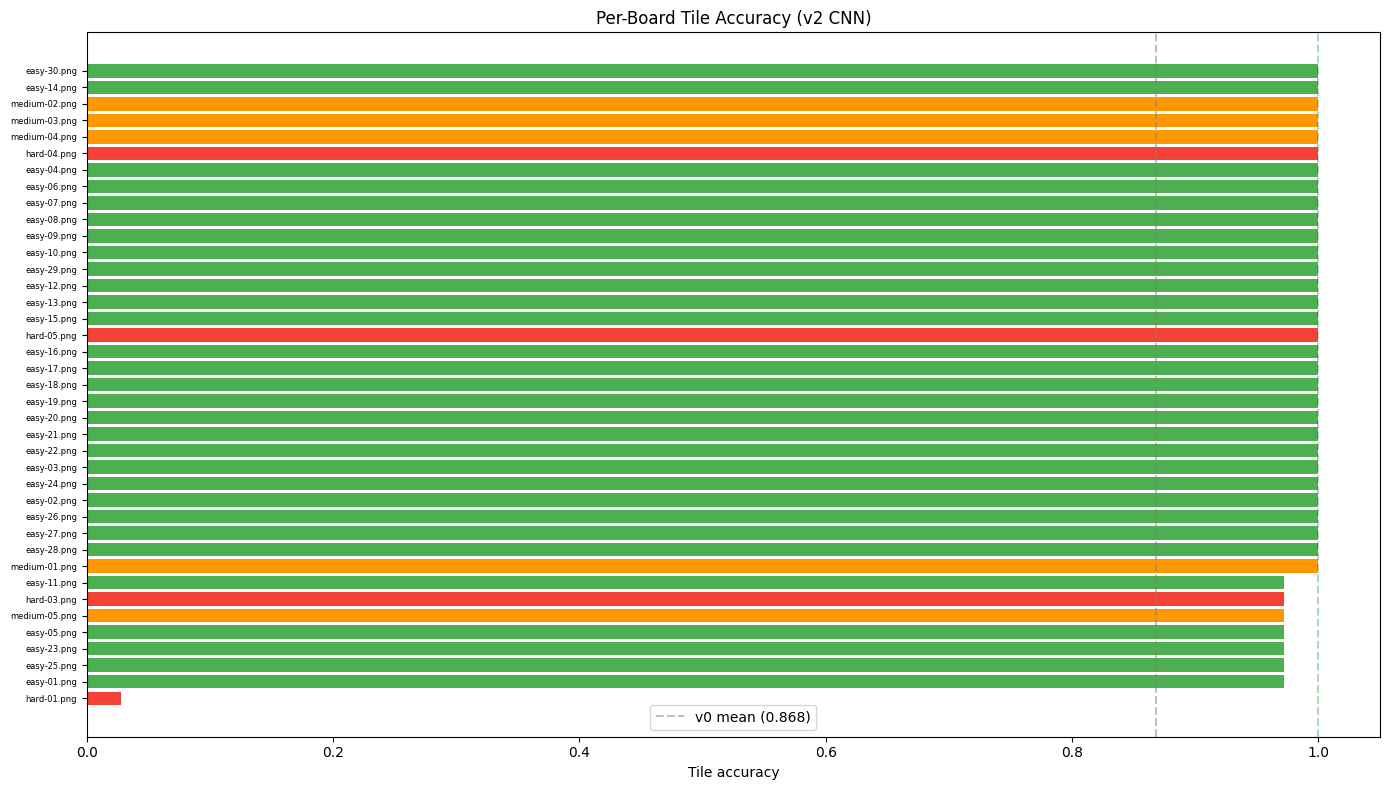

In [16]:
# Per-board accuracy distribution
if len(scored) > 0:
    board_acc = scored.sort_values("tile_accuracy")
    
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = {
        "easy": "#4caf50", "medium": "#ff9800", "hard": "#f44336"
    }
    bar_colors = [colors.get(d, "gray") for d in board_acc["difficulty"]]
    ax.barh(range(len(board_acc)), board_acc["tile_accuracy"].values, color=bar_colors)
    ax.set_yticks(range(len(board_acc)))
    ax.set_yticklabels(board_acc["filename"].values, fontsize=6)
    ax.set_xlabel("Tile accuracy")
    ax.set_title("Per-Board Tile Accuracy (v2 CNN)")
    ax.axvline(0.868, color="gray", linestyle="--", alpha=0.5, label="v0 mean (0.868)")
    ax.axvline(1.0, color="green", linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## M. Summary

In [17]:
print("=" * 60)
print("  BOGGLECNN V2 TRAINING SUMMARY")
print("=" * 60)
print(f"  Training data:        {X.shape[0]} tiles ({X.shape})")
print(f"  Split:                {n_train} train / {n_val} val / {n_test} test")
print(f"  Architecture:         BoggleCNN ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"  Optimizer:            Adam(lr=0.0025)")
print(f"  Epochs:               {NUM_EPOCHS}")
print(f"  Test accuracy:        {test_acc:.4f}")
print(f"  Model saved:          {save_path}")
print(f"  ONNX saved:           {onnx_path}")
print()
print(f"  End-to-end results:")
print(f"    v0 CNN tile acc:    0.868")
print(f"    v2 CNN tile acc:    {v2_acc:.3f}")
print(f"    Improvement:        {v2_acc - 0.868:+.3f}")
if len(ok_only) > 0:
    print(f"    Exact-match boards: {ok_only['board_exact_match'].sum()}/{len(ok_only)}")
print("=" * 60)

  BOGGLECNN V2 TRAINING SUMMARY
  Training data:        44800 tiles ((44800, 100, 100))
  Split:                38080 train / 4480 val / 2240 test
  Architecture:         BoggleCNN (419,744 params)
  Optimizer:            Adam(lr=0.0025)
  Epochs:               3
  Test accuracy:        0.9955
  Model saved:          /Users/thubbard/Documents/personal/programming/boggle-vision/prototyping/legacy/models/boggle_cnn_v2.pth
  ONNX saved:           /Users/thubbard/Documents/personal/programming/boggle-vision/prototyping/legacy/models/boggle_cnn_v2.onnx

  End-to-end results:
    v0 CNN tile acc:    0.868
    v2 CNN tile acc:    0.995
    Improvement:        +0.127
    Exact-match boards: 31/38
